# Pedestrian Crash Severity Prediction in London
## Integrating Road Network Topology Features with Machine Learning

**Course:** CASA0006 / [Your Course Code]  
**Student:** [Your Name]  
**Date:** April 2026

---

## Abstract

> This notebook investigates pedestrian crash severity prediction in London using five years of STATS19 data (2019–2023). We address two limitations common in the literature: (1) the tendency to merge Fatal and Serious injury classes, which obscures policy-relevant distinctions; and (2) the neglect of road network topology as a predictor of crash outcomes. We introduce edge betweenness centrality as a novel feature representing road segment traffic flow potential, and systematically compare prediction performance with and without this network feature. Given the severe class imbalance in the dataset (Fatal: 1.2%, Serious: 25.7%, Slight: 73.4%), we employ class weighting, joint threshold optimisation, and evaluate models using G-mean and macro F1-score rather than accuracy. Results show that [to be completed].

---

## Table of Contents

1. [Research Context and Questions](#1-research-context-and-questions)
2. [Data Collection and Preparation](#2-data-collection-and-preparation)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Network Feature Engineering](#4-network-feature-engineering)
5. [Methodology](#5-methodology)
6. [Series A: Baseline Models (STATS19 Features Only)](#6-series-a-baseline-models)
7. [Series B: Enhanced Models (+ Network Features)](#7-series-b-enhanced-models)
8. [Results and Comparison](#8-results-and-comparison)
9. [Interpretability: SHAP Analysis](#9-interpretability-shap-analysis)
10. [Discussion](#10-discussion)
11. [Conclusion](#11-conclusion)

---
## 2. Data Collection and Preparation
*(Marking criterion: Data collection, handling, and presentation — 15%)*

### 2.1 Data Sources

| Dataset | Source | Coverage | Variables Used |
|---------|--------|----------|----------------|
| STATS19 Collisions | DfT Open Data | 2019–2023 | severity, speed, weather, light, road type, junction |
| STATS19 Casualties | DfT Open Data | 2019–2023 | casualty_severity, vehicle_type, age_of_vehicle |
| STATS19 Vehicles | DfT Open Data | 2019–2023 | ---------, ---------, --------- |
| OS Road Network | OSMnx (OpenStreetMap) | Greater London | geometry, edge betweenness centrality |

### 2.2 Data Loading

In [31]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Spatial Libraries ─────────────────────────────────────────────────────────
import osmnx as ox
import networkx as nx
import igraph as ig
from shapely.geometry import Point

# ── ML Libraries ──────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.metrics import geometric_mean_score
import shap

# ── Plot Settings ─────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
COLORS = {'Fatal': '#d62728', 'Serious': '#ff7f0e', 'Slight': '#2ca02c'}

print("Libraries loaded successfully")

Libraries loaded successfully


In [32]:
# ── Load STATS19 Data ─────────────────────────────────────────────────────────

# Load London LSOA (Lower Layer Super Output Area) boundaries to define the geographic study area
lon_lsoa = gpd.read_file('../Data/statistical-gis-boundaries-london/ESRI/LSOA_2011_London_gen_MHW.shp')

# Load raw collision data (contains coordinates and environmental factors)
collision = pd.read_csv('../Data/dft-road-casualty-statistics-collision-last-5-years.csv')

# Perform an inner merge to keep only accidents that occurred within London LSOA boundaries
lon_collision_5Y = lon_lsoa.merge(collision, left_on='LSOA11CD', right_on='lsoa_of_accident_location', how='inner')

# Data Deduplication: STATS19 records can sometimes overlap or be recorded multiple times
lon_collision_5Y = lon_collision_5Y.drop_duplicates(subset=["collision_ref_no"], keep='first')

# Load casualty data (contains details about people injured)
casualty = pd.read_csv('../Data/dft-road-casualty-statistics-casualty-last-5-years.csv')

# Filter for Pedestrians only (casualty_type == 0 is the code for pedestrians in STATS19)
pedestrain_casualty = casualty[casualty["casualty_type"] == 0]

# One accident can have multiple casualties. We prioritize the most severe injury 
# (Note: In STATS19, 1 = Fatal, 2 = Serious, 3 = Slight, so ascending order captures highest severity)
pedestrain_most_severe = pedestrain_casualty.sort_values(
    by=['collision_index', 'casualty_severity'], 
    ascending=[True, True]
).drop_duplicates(subset=['collision_index'], keep='first')

# Load vehicle data (contains details about engine size, vehicle age, etc.)
vehicle = pd.read_csv('../Data/dft-road-casualty-statistics-vehicle-last-5-years.csv')

# Merge filtered London collisions with the most severe pedestrian casualty records
lon_pedestrain_casualty_collision = pd.merge(pedestrain_most_severe, lon_collision_5Y, on='collision_index', how='inner')

# Join with vehicle data to identify the vehicle involved in the pedestrian hit
lon_pedestrain_collision_5y = pd.merge(lon_pedestrain_casualty_collision, vehicle, on='collision_index', how='left')

# In multi-vehicle accidents, filter for the primary vehicle (reference 1) to simplify the analysis
# to the most likely vehicle that struck the pedestrian.
lon_pedestrain_collision_5y = lon_pedestrain_collision_5y[lon_pedestrain_collision_5y["vehicle_reference_y"] == 1]

# give the table a simple name `df`
df = lon_pedestrain_collision_5y

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['casualty_severity'].value_counts())
print(f"\nMissing values:")

Dataset shape: (19963, 112)

Class distribution:
casualty_severity
3    14614
2     5116
1      233
Name: count, dtype: int64

Missing values:


### 2.3 Data Cleaning and Feature Selection

In [33]:
# ── Missing Value Imputation ───────────────────────────────────────────────────
# STATS19 uses '-1' to represent 'Data missing or out of range'
# Converting to NaN allows for proper imputation or exclusion during machine learning
df.replace(-1, np.nan, inplace=True)

# ── Cyclic Encoding for Hour ───────────────────────────────────────────────────
# extract 'hour' from the 'time' string to create a cyclical numerical feature for the model
time_dt = pd.to_datetime(df['time'], format='%H:%M', errors='coerce')

df['hour_continuous'] = time_dt.dt.hour + time_dt.dt.minute / 60.0

df['hour_sin'] = np.sin(2 * np.pi * df['hour_continuous'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_continuous'] / 24)

# ── Cyclic Collision Monthh ───────────────────────────────────────────────────
dt_series = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')
month = dt_series.dt.month
df['month_sin'] = np.sin(2 * np.pi * month / 12)
df['month_cos'] = np.cos(2 * np.pi * month / 12)

# Remove original 'time', 'hour', 'date' column to maintain feature matrix integrity
df.drop(columns=['time', 'hour_continuous', 'date'], inplace=True)

# Final Integrity Check: Drop rows missing the Target (severity) or spatial data
# Without coordinates, the record cannot be snapped to the road network later.
df.dropna(subset=['casualty_severity'], inplace=True)
df.dropna(subset=['longitude', 'latitude'], inplace=True)

# ── Feature Selection ─────────────────────────────────────────────────────────
cols_selected = [                               
    # ── Environmental Context ──────────────────────────────────────────
    'speed_limit', 
    'light_conditions', 
    'weather_conditions', 
    'road_surface_conditions',
    'road_type', 
    'junction_detail', 
    'junction_control',
    'urban_or_rural_area',

    # ── Temporal Features (Cyclic & Linear) ────────────────────────────
    'hour_sin', 'hour_cos',           # High-precision time
    'month_sin', 'month_cos',         # Seasonal continuity
    'day_of_week',                    # Social behavior (1-7)
    'collision_year',                           # Yearly trend (Recommended)

    # ── Vehicle Characteristics ────────────────────────────────────────
    'vehicle_type', 
    'engine_capacity_cc', 
    'age_of_vehicle', 
    'propulsion_code',

    # ── Human Factors  ──────────────────────────────────────────────────
    'age_of_driver', 
    'sex_of_driver',
    
    # ── Casuality Factors  ───────────────────────────────────────────────
    'sex_of_casualty', 'age_of_casualty'   
]

df['casualty_severity'] = df['casualty_severity'].replace({1: 1, 2: 1, 3: 0})

X = df[cols_selected].copy()
y = df['casualty_severity'].copy()


print(f"Final feature matrix shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")
print(df.notnull().sum())

Final feature matrix shape: (19963, 22)
Features: ['speed_limit', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'road_type', 'junction_detail', 'junction_control', 'urban_or_rural_area', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week', 'collision_year', 'vehicle_type', 'engine_capacity_cc', 'age_of_vehicle', 'propulsion_code', 'age_of_driver', 'sex_of_driver', 'sex_of_casualty', 'age_of_casualty']
collision_index            19963
collision_year_x           19963
collision_ref_no_x         19963
vehicle_reference_x        19963
casualty_reference         19963
                           ...  
driver_distance_banding     2352
hour_sin                   19963
hour_cos                   19963
month_sin                  19963
month_cos                  19963
Length: 114, dtype: int64


### 2.4 Train / Validation / Test Split

We use a stratified 60/20/20 split. The validation set is held out for threshold tuning only — it is never used for model training. The test set is touched only once for final evaluation.

In [34]:
# ── Stratified Split ──────────────────────────────────────────────────────────
# stratify=y ensures Fatal/Serious/Slight proportions are preserved in each split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=63, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=63, stratify=y_temp
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

Train: 11,977 | Val: 3,993 | Test: 3,993

Class distribution in test set:
casualty_severity
0    2923
1    1070
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis
*(Marking criterion: Correctness, depth, and scope — 35% | Visualisation — 10%)*

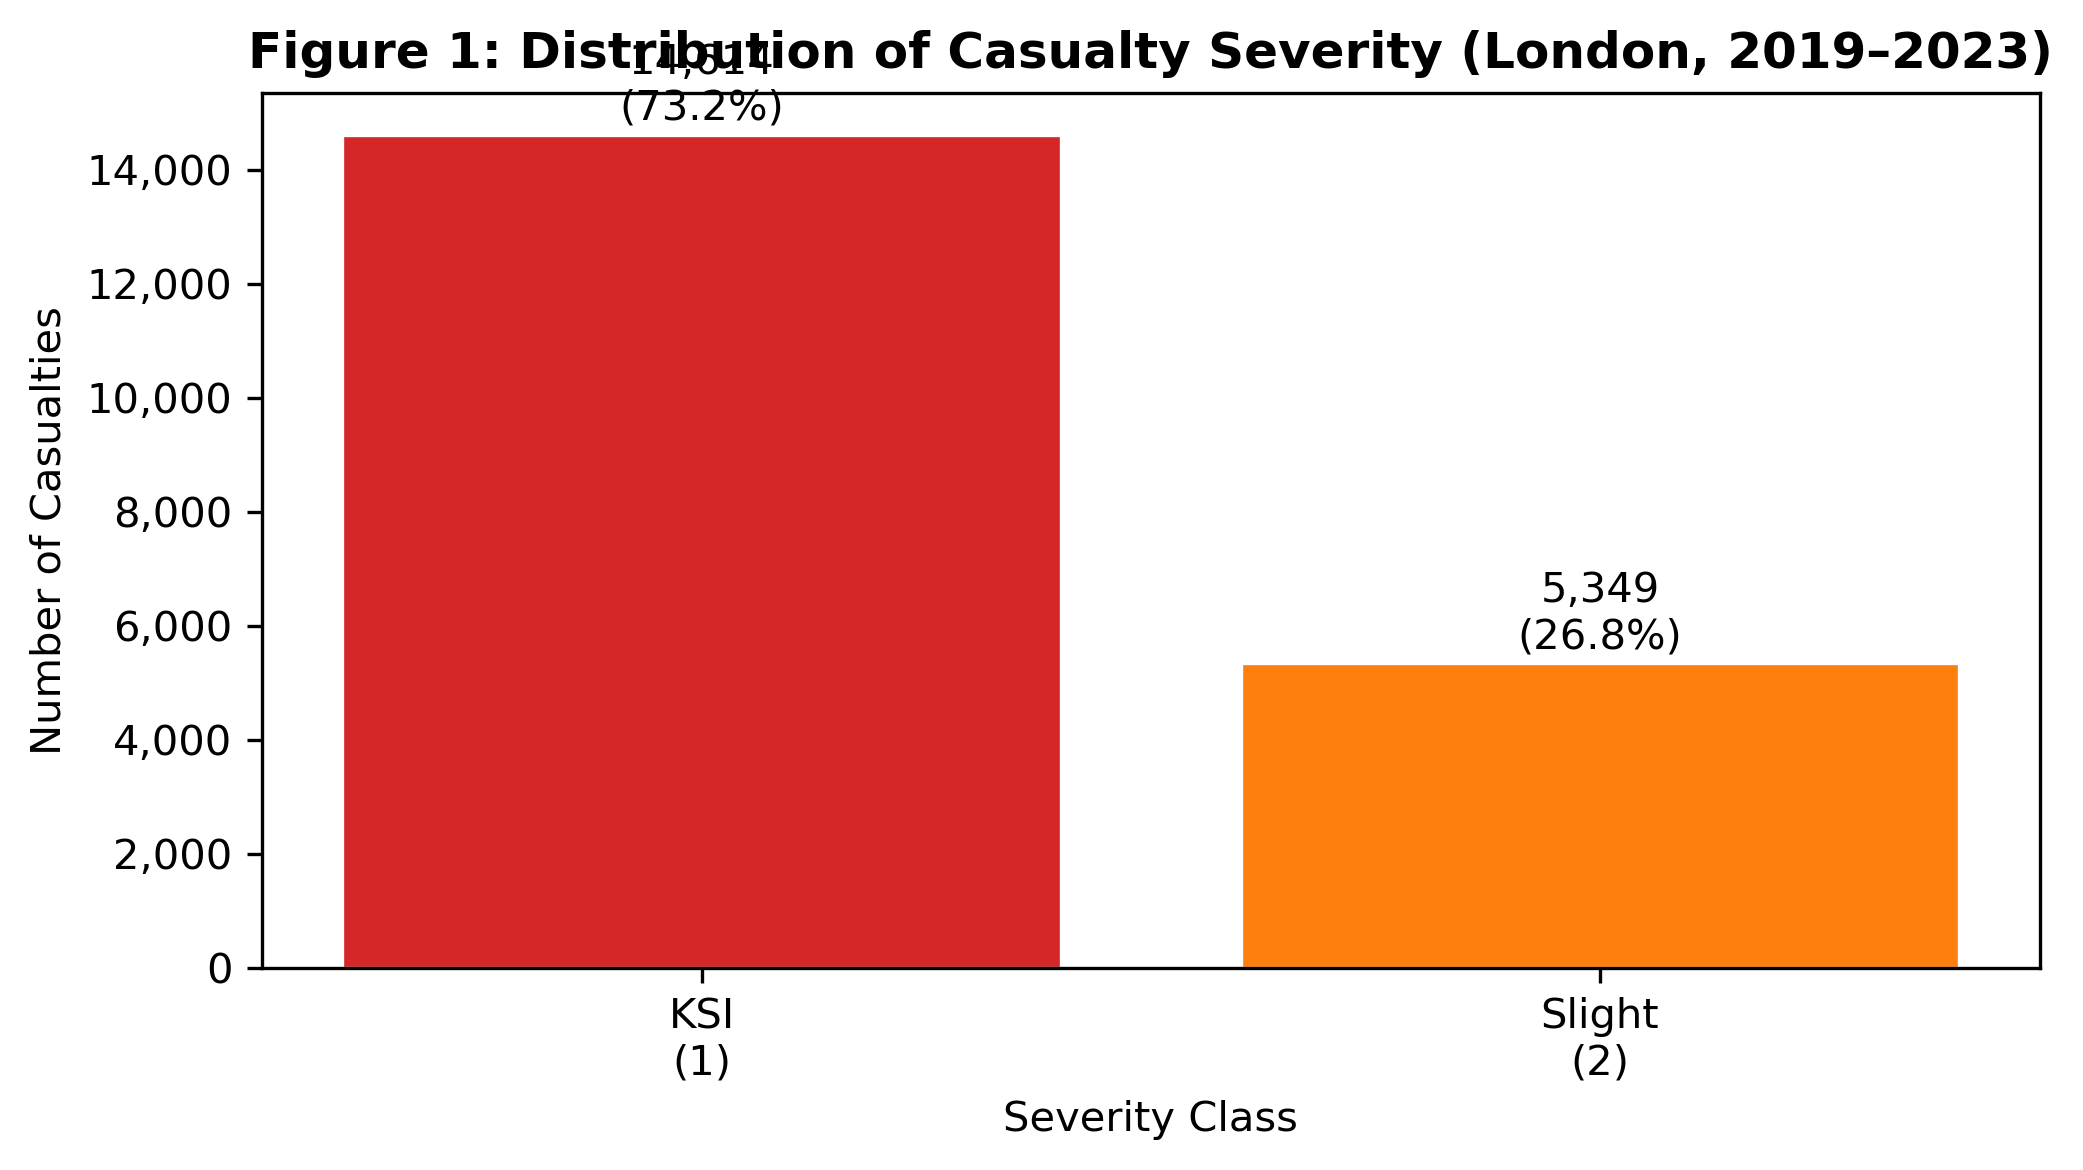


Class imbalance ratios:


KeyError: 3

In [35]:
# ── Figure 1: Class Distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

counts = y.value_counts().sort_index()
bars = ax.bar(
    ['KSI\n(1)', 'Slight\n(2)'],
    counts.values,
    color=[COLORS['Fatal'], COLORS['Serious'], COLORS['Slight']],
    edgecolor='white', linewidth=0.8
)

for bar, count in zip(bars, counts.values):
    pct = count / len(y) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Figure 1: Distribution of Casualty Severity (London, 2019–2023)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Casualties')
ax.set_xlabel('Severity Class')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../figure/fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClass imbalance ratios:")
print(f"  Slight:Fatal   = {counts[3]/counts[1]:.0f}:1")
print(f"  Slight:Serious = {counts[3]/counts[2]:.1f}:1")

---
## 6. Series A: Baseline Models (STATS19 Features Only)
*(Marking criterion: Correctness, depth, and scope — 35%)*

In [38]:
# ── Series A: Feature Matrix (no betweenness) ─────────────────────────────────
# Use X_train, X_val, X_test from Section 2.4
# (already defined above without betweenness)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=63)

param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 1, 3, 5],
    'min_samples_split': [5, 8, 10],
    'class_weight':      ['balanced', {1: 5, 2: 1}]
}

# ── Random Forest ─────────────────────────────────────────────────────────────
gs_rf_A = GridSearchCV(
    RandomForestClassifier(random_state=63),
    param_grid_rf, cv=skf, scoring='recall_macro', n_jobs=1, verbose=1,
)
gs_rf_A.fit(X_train, y_train)
print(f"RF-A Best params: {gs_rf_A.best_params_}")
print(f"RF-A Best recall_macro (CV): {gs_rf_A.best_score_:.3f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
RF-A Best params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 8, 'n_estimators': 200}
RF-A Best recall_macro (CV): 0.615


In [42]:
# ── Threshold Tuning: RF Series A (binary KSI vs Slight) ──────────────────────
# KSI=1, Slight=0. Tune single threshold on P(KSI) to maximise val G-mean.
from sklearn.metrics import precision_score, roc_auc_score
y_val_proba  = gs_rf_A.best_estimator_.predict_proba(X_val)[:, 1]  # P(KSI)
y_test_proba = gs_rf_A.best_estimator_.predict_proba(X_test)[:, 1]

best_t, best_gmean = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.02):
    y_pred_val = (y_val_proba >= t).astype(int)
    g = geometric_mean_score(y_val, y_pred_val, average='macro')
    if g > best_gmean:
        best_gmean, best_t = g, t

print(f"\nRF-A  KSI threshold:     {best_t:.2f}")
print(f"RF-A  G-mean on val:     {best_gmean:.3f}")

# ── Evaluate RF Series A ──────────────────────────────────────────────────────
y_rf_tuned   = (y_test_proba >= best_t).astype(int)
y_rf_default = gs_rf_A.best_estimator_.predict(X_test)

results_rfA = {
    'Model':            'RF (Series A)',
    'KSI Recall':       recall_score(y_test, y_rf_tuned, pos_label=1),
    'Slight Recall':    recall_score(y_test, y_rf_tuned, pos_label=0),
    'KSI Precision':    precision_score(y_test, y_rf_tuned, pos_label=1),
    'Macro F1':         f1_score(y_test, y_rf_tuned, average='macro'),
    'G-mean':           geometric_mean_score(y_test, y_rf_tuned, average='macro'),
    'Default G-mean':   geometric_mean_score(y_test, y_rf_default, average='macro'),
    'Default Macro F1': f1_score(y_test, y_rf_default, average='macro'),
    'ROC-AUC':          roc_auc_score(y_test, y_test_proba),
}

print("\n── RF Series A Results ──")
print(classification_report(y_test, y_rf_tuned, target_names=['Slight', 'KSI']))
print(f"G-mean (tuned):   {results_rfA['G-mean']:.3f}")
print(f"G-mean (default): {results_rfA['Default G-mean']:.3f}")
print(f"ROC-AUC:          {results_rfA['ROC-AUC']:.3f}")


RF-A  KSI threshold:     0.52
RF-A  G-mean on val:     0.607

── RF Series A Results ──
              precision    recall  f1-score   support

      Slight       0.80      0.69      0.74      2923
         KSI       0.38      0.52      0.44      1070

    accuracy                           0.65      3993
   macro avg       0.59      0.61      0.59      3993
weighted avg       0.69      0.65      0.66      3993

G-mean (tuned):   0.607
G-mean (default): 0.616
ROC-AUC:          0.658



--- Feature Importance Ranking (SHAP) ---
         feature  importance
 age_of_casualty    0.037160
   sex_of_driver    0.029572
   age_of_driver    0.022406
light_conditions    0.010768
        hour_cos    0.010729
       road_type    0.009007
 junction_detail    0.008217
junction_control    0.007355
    vehicle_type    0.004469
 propulsion_code    0.003455

图片已成功保存至: shap_summary_rf_series_A.png


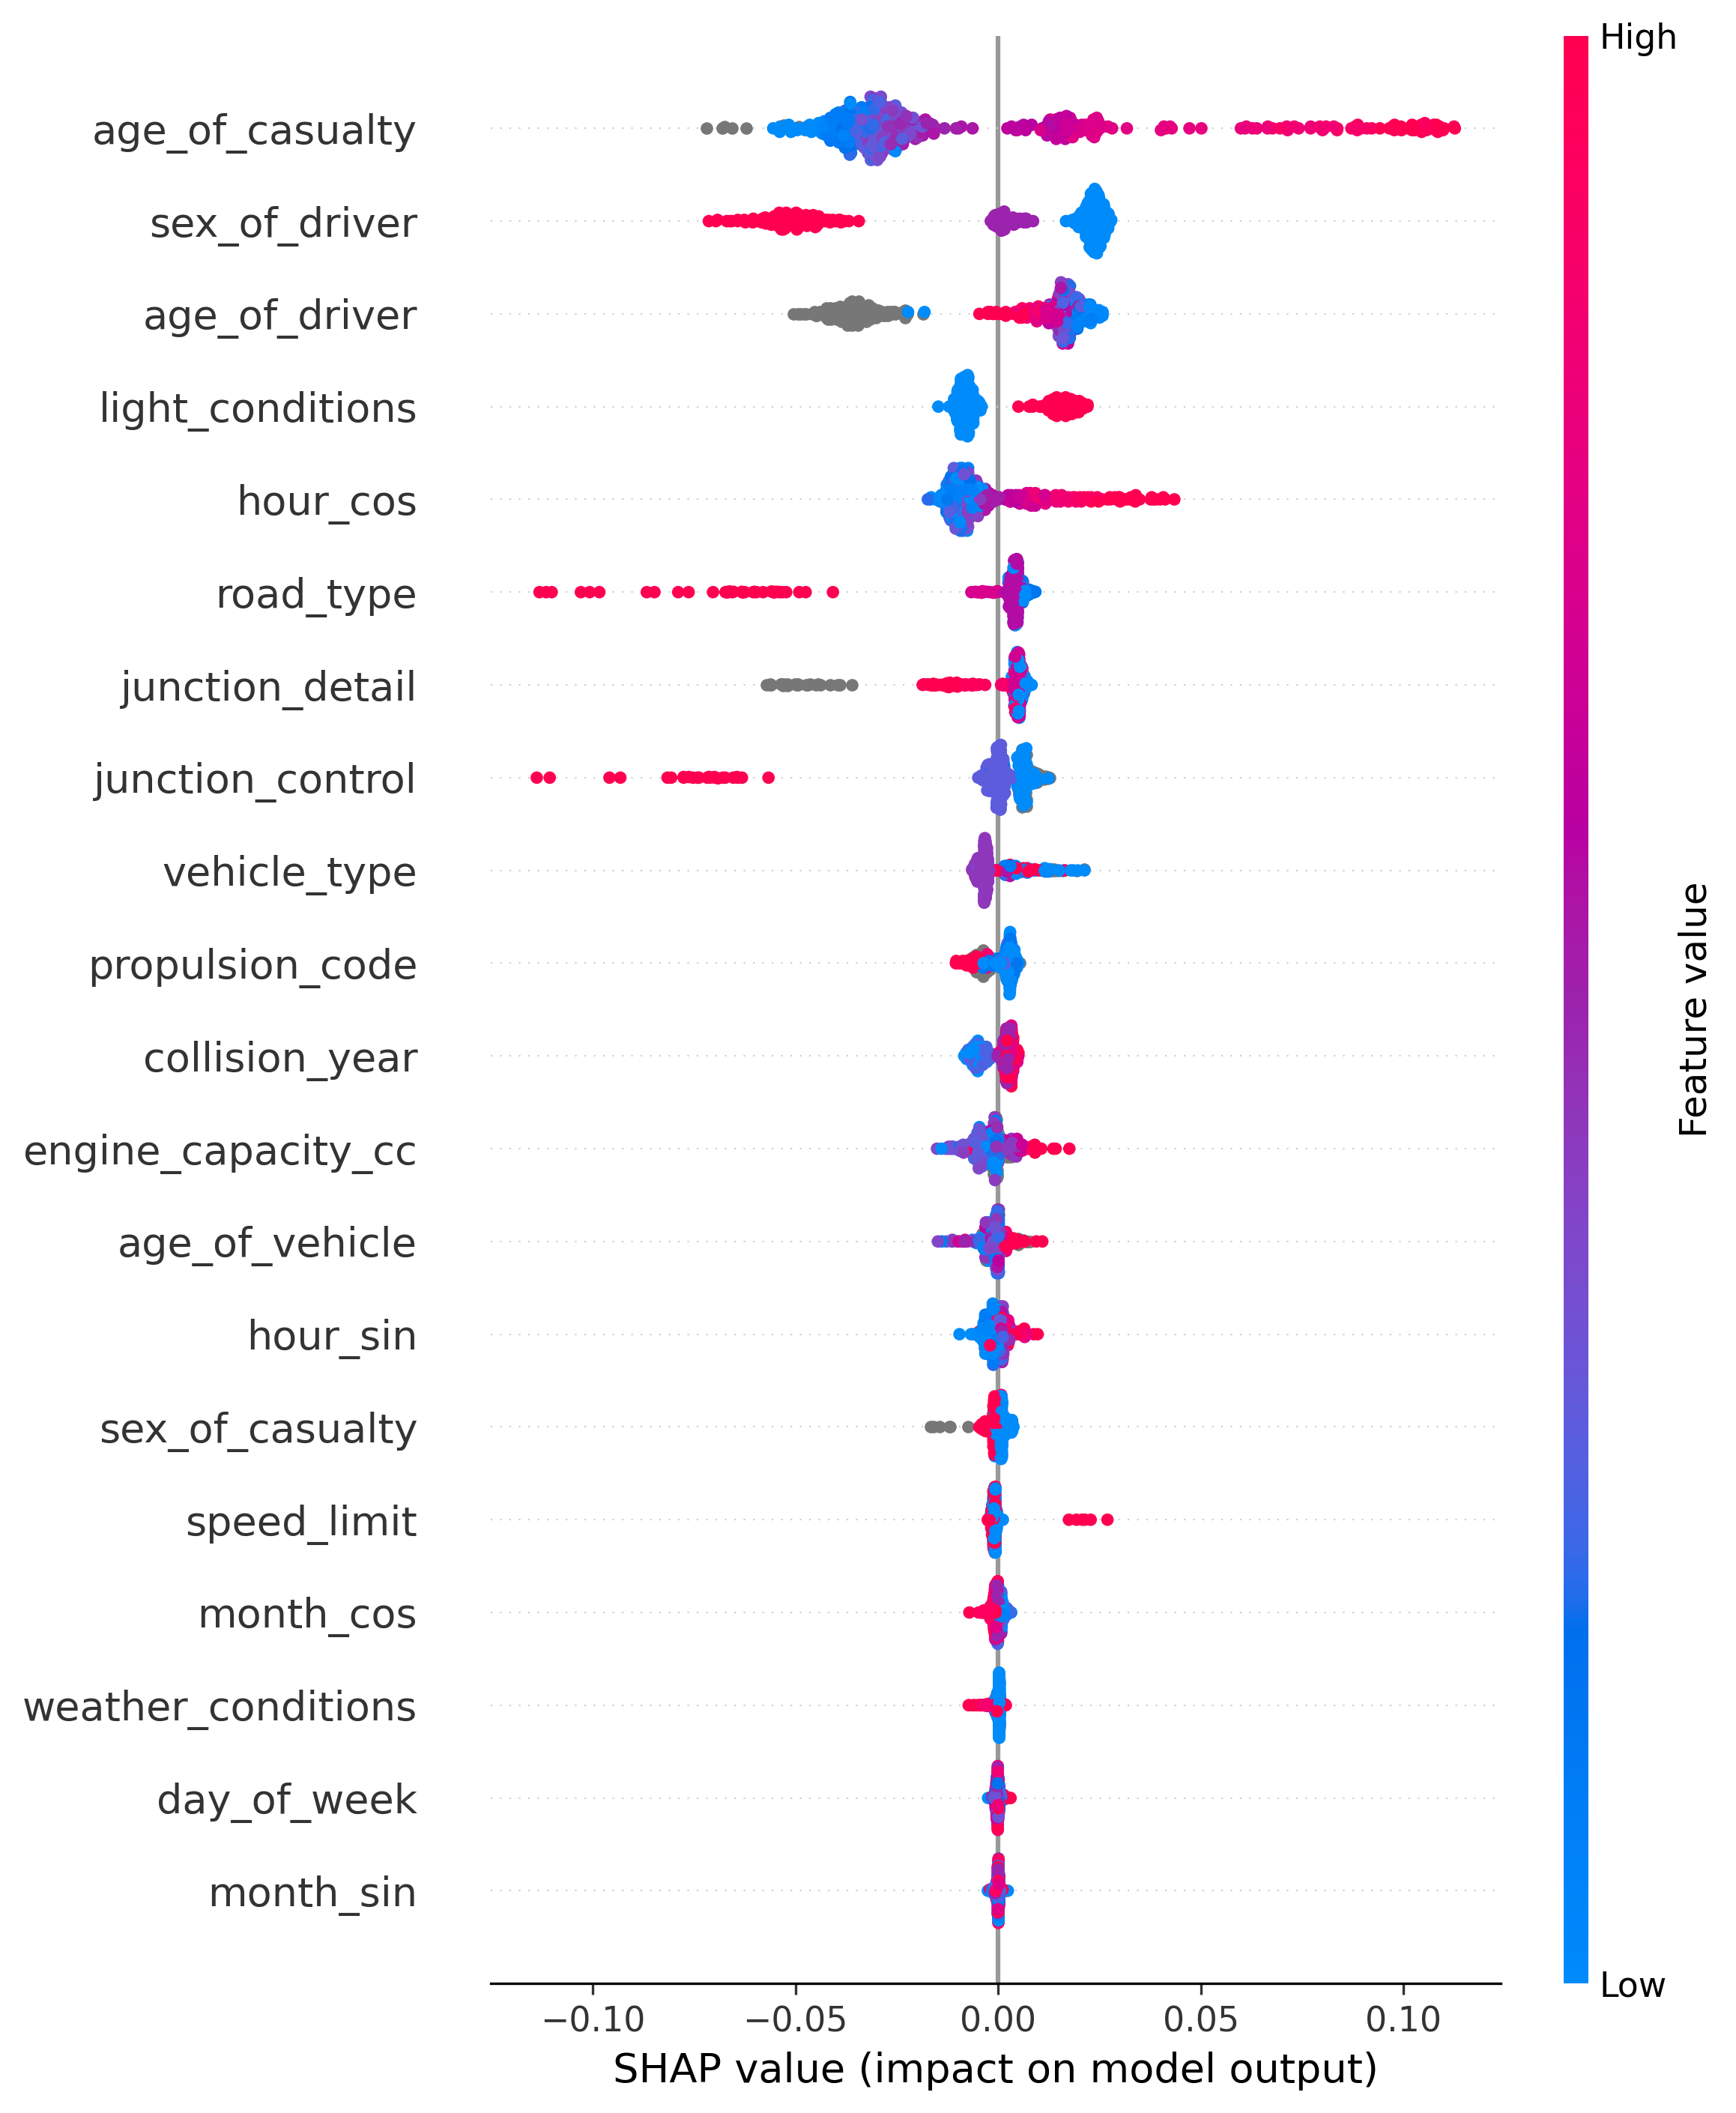

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import shap
import numpy as np

# --- 1. 计算重要性排名并输出文本 ---
global_importances = np.abs(actual_shap_values).mean(0)
feature_importance_df = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': global_importances
}).sort_values(by='importance', ascending=False)

print("\n--- Feature Importance Ranking (SHAP) ---")
print(feature_importance_df.head(10).to_string(index=False))

# --- 2. 绘制并保存图片 ---
# 增加 figsize 确保图片比例美观，适合展示更多特征
plt.figure(figsize=(10, 8))

# 关键点：设置 show=False，否则图片显示后会被清空，无法保存
shap.summary_plot(
    actual_shap_values, 
    X_sample, 
    feature_names=X_sample.columns,
    plot_type="dot",
    show=False
)

# 3. 自动调整布局防止标签重叠
plt.tight_layout()

# 4. 保存为高分辨率图片 (支持 .png, .pdf, .svg, .jpg)
file_name = "shap_summary_rf_series_A.png"
plt.savefig(file_name, dpi=300, bbox_inches='tight')

print(f"\n图片已成功保存至: {file_name}")

# 如果在 Jupyter 中还想看一眼图，可以最后调用 show
plt.show()

In [ ]:
# ── XGBoost Series A (binary KSI vs Slight) ───────────────────────────────────
param_grid_xgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

# Handle class imbalance: scale_pos_weight = n_neg / n_pos
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

gs_xgb_A = GridSearchCV(
    XGBClassifier(
        random_state=24,
        eval_metric='logloss',
        scale_pos_weight=scale_pos,
        device='cuda'
    ),
    param_grid_xgb, cv=skf, scoring='recall', n_jobs=1, verbose=1
)
gs_xgb_A.fit(X_train, y_train)
print(f"XGB-A Best params: {gs_xgb_A.best_params_}")
print(f"XGB-A Best recall (CV): {gs_xgb_A.best_score_:.3f}")

In [23]:
# ── Threshold Tuning: XGBoost Series A (binary KSI vs Slight) ─────────────────
y_val_proba  = gs_xgb_A.best_estimator_.predict_proba(X_val)[:, 1]   # P(KSI)
y_test_proba = gs_xgb_A.best_estimator_.predict_proba(X_test)[:, 1]

best_t, best_gmean = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.02):
    y_pred_val = (y_val_proba >= t).astype(int)
    g = geometric_mean_score(y_val, y_pred_val, average='macro')
    if g > best_gmean:
        best_gmean, best_t = g, t

print(f"\nXGB-A  KSI threshold:    {best_t:.2f}")
print(f"XGB-A  G-mean on val:    {best_gmean:.3f}")

# ── Evaluate XGBoost Series A ─────────────────────────────────────────────────
y_xgb_tuned   = (y_test_proba >= best_t).astype(int)
y_xgb_default = gs_xgb_A.best_estimator_.predict(X_test)

results_xgbA = {
    'Model':            'XGBoost (Series A)',
    'KSI Recall':       recall_score(y_test, y_xgb_tuned, pos_label=1),
    'Slight Recall':    recall_score(y_test, y_xgb_tuned, pos_label=0),
    'KSI Precision':    precision_score(y_test, y_xgb_tuned, pos_label=1),
    'Macro F1':         f1_score(y_test, y_xgb_tuned, average='macro'),
    'G-mean':           geometric_mean_score(y_test, y_xgb_tuned, average='macro'),
    'Default G-mean':   geometric_mean_score(y_test, y_xgb_default, average='macro'),
    'Default Macro F1': f1_score(y_test, y_xgb_default, average='macro'),
    'ROC-AUC':          roc_auc_score(y_test, y_test_proba),
}

print("\n── XGBoost Series A Results ──")
print(classification_report(y_test, y_xgb_tuned, target_names=['Slight', 'KSI']))
print(f"G-mean (tuned):   {results_xgbA['G-mean']:.3f}")
print(f"G-mean (default): {results_xgbA['Default G-mean']:.3f}")
print(f"ROC-AUC:          {results_xgbA['ROC-AUC']:.3f}")


XGB-A  KSI threshold:    0.52
XGB-A  G-mean on val:    0.617

── XGBoost Series A Results ──
              precision    recall  f1-score   support

      Slight       0.81      0.68      0.74      2923
         KSI       0.39      0.56      0.46      1070

    accuracy                           0.65      3993
   macro avg       0.60      0.62      0.60      3993
weighted avg       0.70      0.65      0.67      3993

G-mean (tuned):   0.623
G-mean (default): 0.624
ROC-AUC:          0.671


In [24]:
results_xgbA

{'Model': 'XGBoost (Series A)',
 'KSI Recall': 0.5635514018691589,
 'Slight Recall': 0.6828600752651386,
 'KSI Precision': 0.3941176470588235,
 'Macro F1': 0.6025134965294638,
 'G-mean': 0.6232057385671488,
 'Default G-mean': 0.624228564303094,
 'Default Macro F1': 0.591848443300565,
 'ROC-AUC': 0.6708093400391992}

In [29]:
import shap
import json

# 1. 提取最优模型
best_xgb = gs_xgb_A.best_estimator_

# 2. 修复 XGBoost 2.0+ 的 base_score 兼容性问题
# 获取 booster 的配置信息
config = json.loads(best_xgb.get_booster().save_config())

# 检查 base_score 是否被包裹在列表中 (比如 "[0.5]" 或 "[5E-1]")
base_score = config['learner']['learner_model_param']['base_score']
if isinstance(base_score, str) and base_score.startswith('['):
    # 去掉括号并转换回干净的 float 字符串
    clean_score = base_score.strip('[]')
    config['learner']['learner_model_param']['base_score'] = clean_score
    
    # 将修改后的配置重新加载回模型
    best_xgb.get_booster().load_config(json.dumps(config))

# 3. 现在再初始化 TreeExplainer 就不会报错了
explainer = shap.TreeExplainer(best_xgb)

# 4. 计算并绘图
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

ValueError: could not convert string to float: '[5E-1]'